In [18]:
from langgraph.graph import StateGraph, START, END
from openai import OpenAI
from typing import TypedDict
from dotenv import load_dotenv
import os

In [19]:
load_dotenv()

True

In [20]:
class BatsManState(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    strike_rate: float
    balls_per_boundary: float
    boundary_percentage: float
    summary: str



In [21]:
def calculate_strike_rate(state: BatsManState):
    # state['strike_rate'] = (state['runs'] / state['balls']) * 100
    # return state

    sr = (state['runs'] / state['balls']) * 100

    return {'strike_rate': sr}



In [22]:
def calculate_balls_per_boundary(state: BatsManState):
    # total_boundaries = state['fours'] + state['sixes']
    # if total_boundaries > 0:
    #     state['balls_per_boundary'] = state['balls'] / total_boundaries
    # else:
    #     state['balls_per_boundary'] = float('inf')  # No boundaries hit
    # return state

    total_boundaries = state['fours'] + state['sixes']
    if total_boundaries > 0:
        balls_per_boundary = state['balls'] / total_boundaries
    else:
        balls_per_boundary = float('inf')  # No boundaries hit
    return {'balls_per_boundary': balls_per_boundary}

In [23]:
def calculate_boundary_percentage(state: BatsManState):
    
    # boundary_percentage = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100 if state['runs'] > 0 else 0
    # state['boundary_percentage'] = boundary_percentage

    # return state

    boundary_percentage = (((state['fours'] * 4) + (state['sixes'] * 6)) / state['runs']) * 100 if state['runs'] > 0 else 0

    return {'boundary_percentage': boundary_percentage}

In [24]:
def summary(state: BatsManState) -> BatsManState:
    
    summary = f"""
    Strike Rate: {state['strike_rate']} \n
    Balls per Boundary: {state['balls_per_boundary']} \n
    Boundary Percentage: {state['boundary_percentage']}%
    """

    state['summary'] = summary

    return state

In [25]:
graph = StateGraph(BatsManState)

In [26]:
graph.add_node("calculate_strike_rate", calculate_strike_rate)
graph.add_node("calculate_balls_per_boundary", calculate_balls_per_boundary)
graph.add_node("calculate_boundary_percentage", calculate_boundary_percentage)
graph.add_node("summary", summary)

In [27]:
graph.add_edge(START, "calculate_strike_rate")
graph.add_edge(START, "calculate_balls_per_boundary")
graph.add_edge(START, "calculate_boundary_percentage")

graph.add_edge("calculate_strike_rate", "summary")
graph.add_edge("calculate_balls_per_boundary", "summary")
graph.add_edge("calculate_boundary_percentage", "summary")

graph.add_edge("summary", END)

In [28]:
workflow = graph.compile()

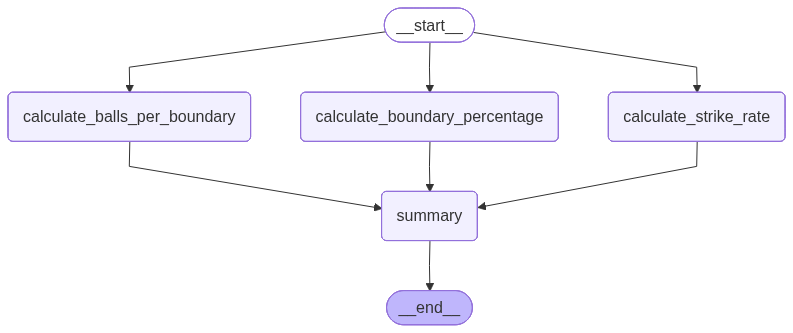

In [29]:
workflow

In [30]:
initial_state = {
    'runs': 120,
    'balls': 80,
    'fours': 10,
    'sixes': 5
}

final_state = workflow.invoke(initial_state)

print(final_state['summary'])


    Strike Rate: 150.0 

    Balls per Boundary: 5.333333333333333 

    Boundary Percentage: 58.333333333333336%
    


Para solucionar esto, en las funciones paralelas no hay que retornar el estado completo, sino solo aquello preciso que se calculó.

In [32]:
initial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(initial_state)

print(final_state['summary'])


    Strike Rate: 200.0 

    Balls per Boundary: 5.0 

    Boundary Percentage: 48.0%
    
